# Validación de Fotometría

Esta libreta verifica el módulo de fotometría paso a paso:
1. Resolución automática del objetivo (WCS con astrometry.net)
2. Detección de fuentes y selección de comparadoras
3. Inspección visual de aperturas sobre el frame de referencia
4. Ejecución del pipeline completo y visualización de la curva de luz diferencial
5. Normalización y de-trending

In [1]:
from pathlib import Path
import sys
import os
import importlib
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd

# --- Carga de variables de entorno desde .env ---
try:
    from dotenv import load_dotenv
    load_dotenv()
except ImportError:
    # Fallback sin python-dotenv: leer .env manualmente
    _env_file = Path.cwd().resolve().parent / '.env' if Path.cwd().name == 'notebooks' else Path.cwd() / '.env'
    if _env_file.exists():
        for _line in _env_file.read_text().splitlines():
            _line = _line.strip()
            if _line and not _line.startswith('#') and '=' in _line:
                _k, _v = _line.split('=', 1)
                os.environ.setdefault(_k.strip(), _v.strip())

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd()
SRC_DIR = PROJECT_ROOT / 'src'
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

ALIGNED_DIR  = PROJECT_ROOT / 'data' / 'aligned'
PHOT_DIR     = PROJECT_ROOT / 'data' / 'photometry'
REF_FRAME    = next(ALIGNED_DIR.glob('ali_*001.fit'))

api_key_ok = bool(os.environ.get("ASTROMETRY_NET_API_KEY"))
print(f"Frame de referencia : {REF_FRAME.name}")
print(f"Salida fotometría   : {PHOT_DIR}")
print(f"API key cargada     : {'OK' if api_key_ok else 'NO ENCONTRADA — revisa el .env'}")


Frame de referencia : ali_cal_qatar1b-001.fit
Salida fotometría   : C:\Users\Daniel\Desktop\En curso\Máster Astrofísica\TFM\data\photometry
API key cargada     : OK


## 1 · Plate scale automático y posición del objetivo

Usa los metadatos del FITS (XPIXSZ, FOCALLEN, XBINNING) para calcular el plate scale
y usa el WCS solver para encontrar las sources

In [2]:
import photometry.io as phot_io
importlib.reload(phot_io)

from astropy.io import fits
header = fits.getheader(REF_FRAME)
"""
plate_scale = phot_io.estimate_pixel_scale_arcsec(header)
print(f"XPIXSZ     : {header.get('XPIXSZ')} µm")
print(f"FOCALLEN   : {header.get('FOCALLEN')} mm")
print(f"XBINNING   : {header.get('XBINNING')}")
print(f"Plate scale: {plate_scale:.3f} arcsec/px")
"""
OBJECT_NAME = 'Qatar 1'
target_x, target_y = phot_io.resolve_target_xy(
    REF_FRAME,
    OBJECT_NAME,
    wcs_solver="online",      # API key se lee automáticamente desde os.environ
    persist_solved_wcs=True,  # cachea el WCS resuelto → frames siguientes son instantáneos
)
print(f"\nPosición de {OBJECT_NAME}: x={target_x:.1f} px, y={target_y:.1f} px")
print(f"Tamaño del frame   : {header['NAXIS1']} × {header['NAXIS2']} px")


[photometry] Target resolved with cached WCS sidecar: (470.7, 203.1)

Posición de Qatar 1: x=470.7 px, y=203.1 px
Tamaño del frame   : 844 × 644 px


## 2 · Detección de fuentes en el frame de referencia

Muestra las estrellas detectadas, marcando el objetivo y las comparadoras elegidas.

In [3]:
import photometry.aperture as phot_ap
importlib.reload(phot_ap)
import reduction.io as reduction_io
importlib.reload(reduction_io)
from astropy.visualization import ZScaleInterval

from photometry.pipeline import PhotometryConfig

config = PhotometryConfig(
    object_name=OBJECT_NAME,
    detection_fwhm=4.5,
    detection_threshold_sigma=5.0,   # umbral bajo para detectar Qatar-1 (V~12.8)
    max_comparisons=12,
)

ref_ccd = reduction_io.load_ccd(str(REF_FRAME))
sources = phot_ap.detect_sources(
    ref_ccd.data,
    fwhm=config.detection_fwhm,
    threshold_sigma=config.detection_threshold_sigma,
    exclude_border=config.exclude_border,
    brightest=config.brightest_sources,
)
target_source = phot_ap.choose_target_source(
    sources,
    image_shape=ref_ccd.data.shape,
    target_xy=(target_x, target_y),
)

snap_dist = float(np.hypot(target_source['x'] - target_x, target_source['y'] - target_y))
print(f"Fuentes detectadas        : {len(sources)}")
print(f"Posición WCS              : ({target_x:.1f}, {target_y:.1f}) px")
print(f"Snap → fuente más cercana : ({target_source['x']:.1f}, {target_source['y']:.1f}) px")
print(f"Distancia de snap         : {snap_dist:.1f} px  ({'OK' if snap_dist < 3*config.detection_fwhm else 'ALERTA: puede no ser Qatar-1'})")

fwhm_est   = config.detection_fwhm
ap_r_est   = max(config.aperture_scale * fwhm_est, 2.0)
ann_r2_est = max(config.annulus_scale_outer * ap_r_est, ap_r_est + 2.0)
effective_min_sep = ann_r2_est + 5.0
min_neighbor_distance = ann_r2_est + ap_r_est + 2.0

comparison_sources = phot_ap.choose_comparison_sources(
    sources,
    target_source=target_source,
    image_shape=ref_ccd.data.shape,
    max_comparisons=config.max_comparisons,
    min_separation=effective_min_sep,
    min_edge_distance=config.min_edge_distance,
)
print(f"Separación mínima al objetivo : {effective_min_sep:.1f} px")
print(f"Aislamiento mínimo a vecinas  : {min_neighbor_distance:.1f} px")
print(f"Comparadoras seleccionadas    : {len(comparison_sources)}")

INFO: using the unit adu passed to the FITS reader instead of the unit adu in the FITS file. [astropy.nddata.ccddata]
Fuentes detectadas        : 181
Posición WCS              : (470.7, 203.1) px
Snap → fuente más cercana : (470.5, 203.9) px
Distancia de snap         : 0.9 px  (OK)
Separación mínima al objetivo : 23.4 px
Aislamiento mínimo a vecinas  : 28.0 px
Comparadoras seleccionadas    : 6


## 3 · Inspección visual de aperturas

Muestra el frame de referencia con los círculos de apertura y anillo de fondo para el objetivo
y las comparadoras. Verde = objetivo, naranja = comparadoras, anillos en azul claro.

FWHM base      : 4.50 px
Apertura       : 7.65 px
Anillo interno : 13.00 px
Anillo externo : 18.36 px


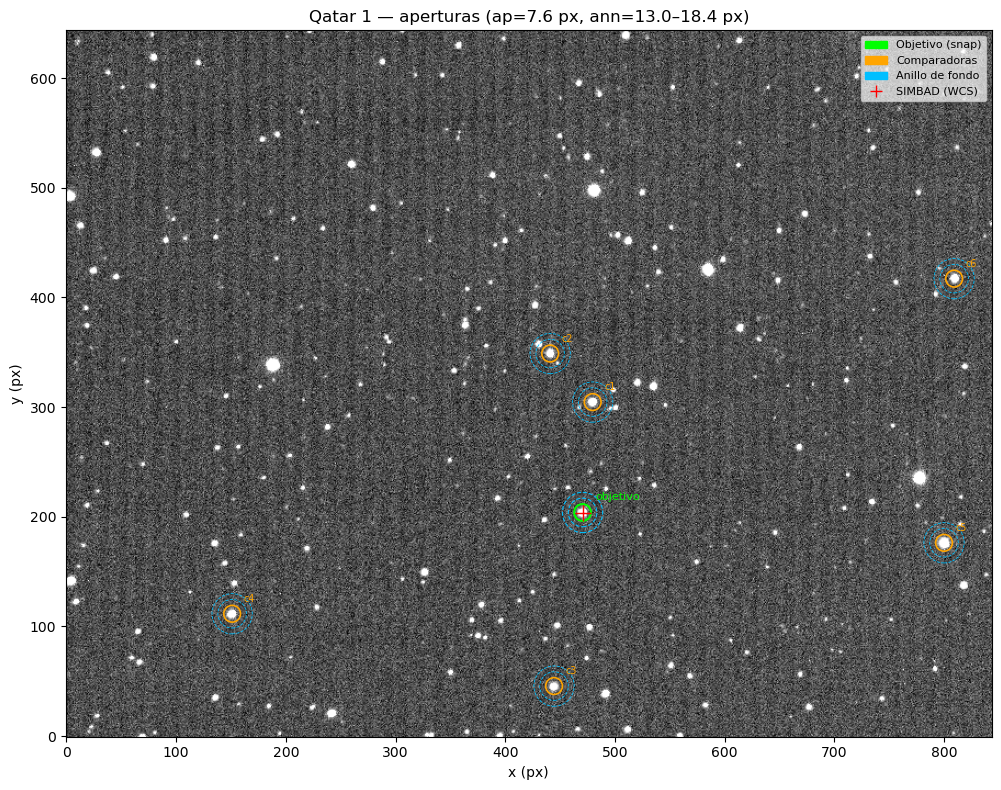

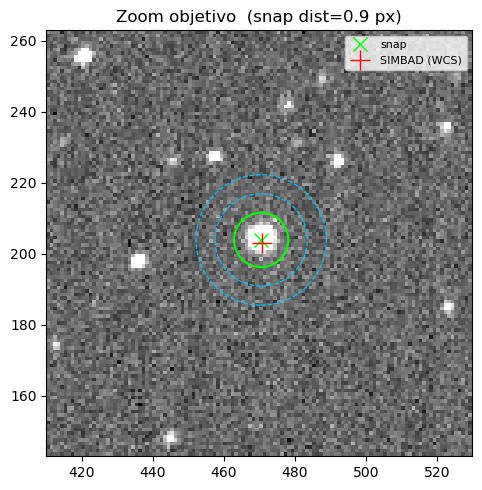

In [4]:
from numpy import median as np_median

# Calcular radios de apertura
fwhm_samples = [target_source.get('fwhm', config.detection_fwhm)]
fwhm_samples += [s.get('fwhm', config.detection_fwhm) for s in comparison_sources]
base_fwhm = float(np_median(fwhm_samples))
ap_r   = max(config.aperture_scale * base_fwhm, 2.0)
ann_r1 = max(config.annulus_scale_inner * ap_r, ap_r + 2.0)
ann_r2 = max(config.annulus_scale_outer * ap_r, ann_r1 + 2.0)

print(f"FWHM base      : {base_fwhm:.2f} px")
print(f"Apertura       : {ap_r:.2f} px")
print(f"Anillo interno : {ann_r1:.2f} px")
print(f"Anillo externo : {ann_r2:.2f} px")

zscale = ZScaleInterval()
vmin, vmax = zscale.get_limits(ref_ccd.data)

# --- Vista global con aperturas ---
fig, ax = plt.subplots(figsize=(11, 8))
ax.imshow(ref_ccd.data, cmap='gray', vmin=vmin, vmax=vmax, origin='lower')

for r, color, lw, ls in [(ap_r, 'lime', 1.5, '-'), (ann_r1, 'deepskyblue', 0.8, '--'), (ann_r2, 'deepskyblue', 0.8, '--')]:
    ax.add_patch(plt.Circle((target_source['x'], target_source['y']), r, color=color, fill=False, lw=lw, ls=ls))
ax.annotate('objetivo', xy=(target_source['x'], target_source['y']),
            xytext=(target_source['x'] + ap_r + 4, target_source['y'] + ap_r + 4),
            color='lime', fontsize=8, ha='left')

for i, c in enumerate(comparison_sources, 1):
    for r, color, lw, ls in [(ap_r, 'orange', 1.2, '-'), (ann_r1, 'deepskyblue', 0.6, '--'), (ann_r2, 'deepskyblue', 0.6, '--')]:
        ax.add_patch(plt.Circle((c['x'], c['y']), r, color=color, fill=False, lw=lw, ls=ls))
    ax.annotate(f'c{i}', xy=(c['x'], c['y']),
                xytext=(c['x'] + ap_r + 3, c['y'] + ap_r + 3),
                color='orange', fontsize=7, ha='left')

ax.plot(target_x, target_y, '+', color='red', ms=12, lw=1.5)
legend_handles = [
    mpatches.Patch(color='lime',        label='Objetivo (snap)'),
    mpatches.Patch(color='orange',      label='Comparadoras'),
    mpatches.Patch(color='deepskyblue', label='Anillo de fondo'),
    plt.Line2D([0], [0], marker='+', color='red', linestyle='None', ms=8, label='SIMBAD (WCS)'),
]
ax.legend(handles=legend_handles, loc='upper right', fontsize=8, framealpha=0.7)
ax.set_title(f'{OBJECT_NAME} — aperturas (ap={ap_r:.1f} px, ann={ann_r1:.1f}–{ann_r2:.1f} px)')
ax.set_xlabel('x (px)')
ax.set_ylabel('y (px)')
plt.tight_layout()
plt.show()

# --- Zoom en la región del objetivo ---
ZOOM_R = max(int(ann_r2 * 3), 60)
tx, ty = int(target_source['x']), int(target_source['y'])
x0, x1 = max(tx - ZOOM_R, 0), min(tx + ZOOM_R, ref_ccd.data.shape[1])
y0, y1 = max(ty - ZOOM_R, 0), min(ty + ZOOM_R, ref_ccd.data.shape[0])

crop = ref_ccd.data[y0:y1, x0:x1]
vmin_z, vmax_z = zscale.get_limits(crop)

fig2, ax2 = plt.subplots(figsize=(5, 5))
ax2.imshow(crop, cmap='gray', vmin=vmin_z, vmax=vmax_z, origin='lower', extent=[x0, x1, y0, y1])
for r, color, lw, ls in [(ap_r, 'lime', 1.5, '-'), (ann_r1, 'deepskyblue', 0.9, '--'), (ann_r2, 'deepskyblue', 0.9, '--')]:
    ax2.add_patch(plt.Circle((target_source['x'], target_source['y']), r, color=color, fill=False, lw=lw, ls=ls))
ax2.plot(target_source['x'], target_source['y'], 'x', color='lime', ms=10, lw=1.5, label='snap')
ax2.plot(target_x, target_y, '+', color='red', ms=14, lw=1.5, label='SIMBAD (WCS)')
ax2.set_title(f'Zoom objetivo  (snap dist={snap_dist:.1f} px)')
ax2.legend(fontsize=8)
plt.tight_layout()
plt.show()


## 4 · Ejecución del pipeline completo

Genera `source_catalog.csv`, `aperture_photometry.csv` y `differential_light_curve.csv`.
Solo es necesario ejecutar esta celda una vez; las siguientes leen los CSV.

In [5]:
import photometry.pipeline as phot_pipeline
importlib.reload(phot_pipeline)
from photometry.pipeline import PhotometryPaths, PhotometryConfig, run_photometry_pipeline

phot_paths = PhotometryPaths(
    aligned_dir=ALIGNED_DIR,
    output_dir=PHOT_DIR,
)
phot_config = PhotometryConfig(
    object_name=OBJECT_NAME,
    max_comparisons=12,
    wcs_solver="online",      # API key desde os.environ (cargada en celda 1)
    persist_solved_wcs=True,
    comparison_brightness_range=(0.3, 3.0),
)

light_curve_table = run_photometry_pipeline(phot_paths, phot_config)
print(f"Puntos de curva de luz: {len(light_curve_table)}")
print(light_curve_table[:5])

[photometry] Target resolved with cached WCS sidecar: (470.7, 203.1)
[photometry] Target 'Qatar 1' resolved to pixel (470.7, 203.1)
INFO: using the unit adu passed to the FITS reader instead of the unit adu in the FITS file. [astropy.nddata.ccddata]
[photometry] Target snap OK: distance = 0.9 px
INFO: using the unit adu passed to the FITS reader instead of the unit adu in the FITS file. [astropy.nddata.ccddata]
INFO: using the unit adu passed to the FITS reader instead of the unit adu in the FITS file. [astropy.nddata.ccddata]
INFO: using the unit adu passed to the FITS reader instead of the unit adu in the FITS file. [astropy.nddata.ccddata]
INFO: using the unit adu passed to the FITS reader instead of the unit adu in the FITS file. [astropy.nddata.ccddata]
INFO: using the unit adu passed to the FITS reader instead of the unit adu in the FITS file. [astropy.nddata.ccddata]
INFO: using the unit adu passed to the FITS reader instead of the unit adu in the FITS file. [astropy.nddata.ccdd

## 5 · Curva de luz diferencial

Flujo relativo normalizado a la mediana. Un tránsito aparece como un descenso por debajo de 1.

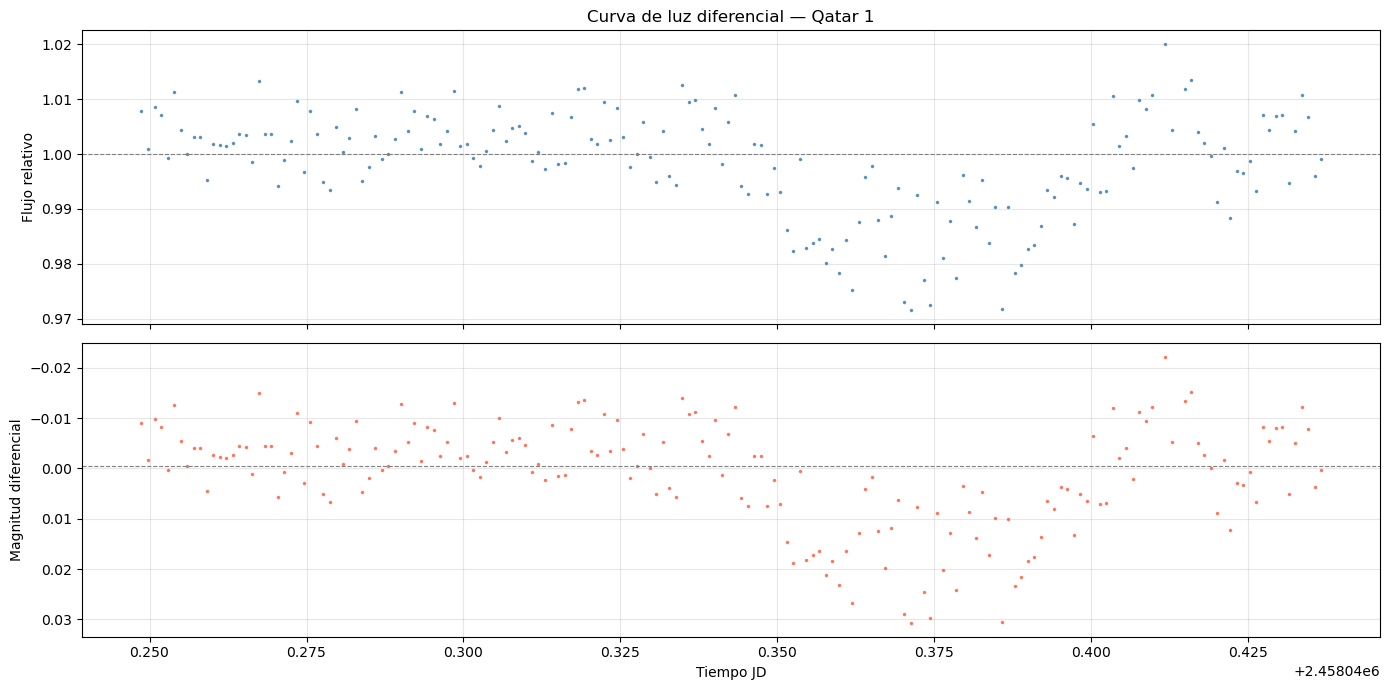

RMS del flujo relativo : 9.55 mmag
Puntos totales         : 180
Comparadoras usadas    : 7


In [6]:

lc = pd.read_csv(PHOT_DIR / 'differential_light_curve.csv')

time_col = 'time_jd' if 'time_jd' in lc.columns and lc['time_jd'].notna().any() else 'frame_index'
x_label  = 'Tiempo JD' if time_col == 'time_jd' else 'Índice de frame'

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

axes[0].plot(lc[time_col], lc['relative_flux'], '.', color='steelblue', ms=3, alpha=0.8)
axes[0].axhline(1.0, color='gray', lw=0.8, linestyle='--')
axes[0].set_ylabel('Flujo relativo')
axes[0].set_title(f'Curva de luz diferencial — {OBJECT_NAME}')
axes[0].grid(True, alpha=0.3)

axes[1].plot(lc[time_col], lc['differential_mag'], '.', color='tomato', ms=3, alpha=0.8)
axes[1].axhline(lc['differential_mag'].median(), color='gray', lw=0.8, linestyle='--')
axes[1].invert_yaxis()
axes[1].set_ylabel('Magnitud diferencial')
axes[1].set_xlabel(x_label)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

rms = float(lc['relative_flux'].std())
print(f"RMS del flujo relativo : {rms*1000:.2f} mmag")
print(f"Puntos totales         : {len(lc)}")
print(f"Comparadoras usadas    : {int(lc['n_comparisons_used'].mode()[0])}")

## 6 · Normalización y detrending

Paso crítico antes de ajuste de tránsito:
1. **Normalización**: escala flujo relativo a 1.0 usando baseline pre-tránsito (primeros ~20-30% de datos)
2. **Detrending polinomial**: remueve tendencias (airmass, FWHM, time-dependence)

Resultado: curva limpia lista para caracterización del tránsito

In [7]:
import photometry.detrending as phot_detrending
importlib.reload(phot_detrending)

# Cargar curva diferencial (si no está ya en memoria)
if 'lc' not in locals() or lc is None:
    lc = pd.read_csv(PHOT_DIR / 'differential_light_curve.csv')

def estimate_beta_oot(residuals: np.ndarray, bin_sizes=(5, 10, 15)) -> float:
    residuals = np.asarray(residuals, dtype=float)
    residuals = residuals[np.isfinite(residuals)]
    if residuals.size < 30:
        return np.nan

    sigma_1 = np.std(residuals, ddof=1)
    if not np.isfinite(sigma_1) or sigma_1 <= 0:
        return np.nan

    beta_vals = []
    for nbin in bin_sizes:
        m = residuals.size // nbin
        if m < 3:
            continue
        trimmed = residuals[:m * nbin]
        binned = trimmed.reshape(m, nbin).mean(axis=1)
        sigma_n = np.std(binned, ddof=1)
        sigma_exp = sigma_1 / np.sqrt(nbin) * np.sqrt(m / (m - 1))
        if np.isfinite(sigma_n) and np.isfinite(sigma_exp) and sigma_exp > 0:
            beta_vals.append(sigma_n / sigma_exp)

    return float(np.median(beta_vals)) if beta_vals else np.nan

def score_from_residuals_oot(resid_oot: np.ndarray):
    rms_oot = float(np.std(resid_oot, ddof=1))
    beta_oot = estimate_beta_oot(resid_oot)
    beta_eff = beta_oot if np.isfinite(beta_oot) else 1.0
    score = rms_oot * max(beta_eff, 0.8)
    return rms_oot, beta_oot, score

# Búsqueda de detrending optimizado con criterio OOT
baseline_ranges = [(0.0, 15.0), (0.0, 20.0), (0.0, 30.0)]
sigma_thresholds = [1.6, 1.8, 2.0]
poly_degrees = [1, 2, 3]

results = []
best_payload = None

for baseline_range in baseline_ranges:
    lc_norm_try = phot_detrending.normalize_to_baseline(
        lc,
        relative_flux_column='relative_flux',
        baseline_percentile_range=baseline_range,
    )

    for sigma_th in sigma_thresholds:
        transit_mask_try = phot_detrending.estimate_transit_mask(
            lc_norm_try,
            normalized_flux_column='normalized_flux',
            threshold_sigma=sigma_th,
        )

        lc_norm_try2 = lc_norm_try.copy()
        lc_norm_try2['in_transit_mask'] = transit_mask_try

        oot_mask_base = ~lc_norm_try2['in_transit_mask'].astype(bool)
        if int(oot_mask_base.sum()) < 25:
            continue

        # Candidato base: sin detrending (solo normalización)
        resid_norm_oot = (lc_norm_try2.loc[oot_mask_base, 'normalized_flux'] - 1.0).to_numpy(dtype=float)
        rms_oot_base, beta_oot_base, score_base = score_from_residuals_oot(resid_norm_oot)

        lc_no_det = lc_norm_try2.copy()
        lc_no_det['trend'] = 1.0
        lc_no_det['detrended_flux'] = lc_no_det['normalized_flux']

        results.append({
            'mode': 'no_detrend',
            'baseline_range': baseline_range,
            'sigma_threshold': sigma_th,
            'degree': 0,
            'n_oot': int(oot_mask_base.sum()),
            'rms_oot_mmag': rms_oot_base * 1000.0,
            'beta_oot': beta_oot_base,
            'score': score_base,
        })

        if best_payload is None or score_base < best_payload['score']:
            best_payload = {
                'lc_norm': lc_norm_try2.copy(),
                'lc_det': lc_no_det.copy(),
                'mode': 'no_detrend',
                'baseline_range': baseline_range,
                'sigma_threshold': sigma_th,
                'degree': 0,
                'n_oot': int(oot_mask_base.sum()),
                'rms_oot_mmag': rms_oot_base * 1000.0,
                'beta_oot': beta_oot_base,
                'score': score_base,
            }

        # Candidatos con detrending polinomial
        for deg in poly_degrees:
            lc_det_try = phot_detrending.detrend_polynomial(
                lc_norm_try2,
                normalized_flux_column='normalized_flux',
                index_column='frame_index',
                degree=deg,
                mask_out_of_transit=False,
                transit_mask_column='in_transit_mask',
                robust=True,
            )

            oot_mask = ~lc_det_try['in_transit_mask'].astype(bool)
            n_oot = int(oot_mask.sum())
            if n_oot < 25:
                continue

            resid_oot = (lc_det_try.loc[oot_mask, 'detrended_flux'] - 1.0).to_numpy(dtype=float)
            rms_oot, beta_oot, score = score_from_residuals_oot(resid_oot)

            results.append({
                'mode': 'poly_detrend',
                'baseline_range': baseline_range,
                'sigma_threshold': sigma_th,
                'degree': deg,
                'n_oot': n_oot,
                'rms_oot_mmag': rms_oot * 1000.0,
                'beta_oot': beta_oot,
                'score': score,
            })

            if score < best_payload['score']:
                best_payload = {
                    'lc_norm': lc_norm_try2.copy(),
                    'lc_det': lc_det_try.copy(),
                    'mode': 'poly_detrend',
                    'baseline_range': baseline_range,
                    'sigma_threshold': sigma_th,
                    'degree': deg,
                    'n_oot': n_oot,
                    'rms_oot_mmag': rms_oot * 1000.0,
                    'beta_oot': beta_oot,
                    'score': score,
                }

if best_payload is None:
    raise RuntimeError('No se encontró una configuración válida de detrending con suficientes puntos OOT.')

# Guardar mejor resultado como salida de la celda
lc_norm = best_payload['lc_norm']
lc_detrended = best_payload['lc_det']
transit_mask = lc_detrended['in_transit_mask'].astype(bool).to_numpy()
oot_mask = ~transit_mask

ranking_detrend = pd.DataFrame(results).sort_values(['score', 'rms_oot_mmag']).reset_index(drop=True)

print('=== Top 10 configuraciones de detrending (solo criterio OOT) ===')
print(ranking_detrend.head(10).to_string(index=False, formatters={
    'rms_oot_mmag': '{:.3f}'.format,
    'beta_oot': lambda v: 'nan' if not np.isfinite(v) else f'{v:.3f}',
    'score': '{:.6f}'.format,
}))

print('\n=== Mejor configuración seleccionada ===')
print(f"modo                    : {best_payload['mode']}")
print(f"baseline_percentile_range: {best_payload['baseline_range']}")
print(f"threshold_sigma         : {best_payload['sigma_threshold']}")
print(f"degree polinomial       : {best_payload['degree']}")
print(f"puntos OOT             : {best_payload['n_oot']}")
print(f"RMS OOT                : {best_payload['rms_oot_mmag']:.3f} mmag")
if np.isfinite(best_payload['beta_oot']):
    print(f"beta OOT               : {best_payload['beta_oot']:.3f}")
else:
    print('beta OOT               : nan')

ranking_detrend.head(10)

=== Top 10 configuraciones de detrending (solo criterio OOT) ===
        mode baseline_range  sigma_threshold  degree  n_oot rms_oot_mmag beta_oot    score
  no_detrend    (0.0, 15.0)              1.6       0    147        5.834    1.729 0.010089
  no_detrend    (0.0, 20.0)              1.6       0    147        5.837    1.729 0.010094
  no_detrend    (0.0, 30.0)              1.6       0    147        5.838    1.729 0.010095
poly_detrend    (0.0, 15.0)              1.6       1    147        6.055    1.758 0.010646
poly_detrend    (0.0, 30.0)              1.6       1    147        6.055    1.758 0.010646
poly_detrend    (0.0, 20.0)              1.6       1    147        6.055    1.758 0.010646
poly_detrend    (0.0, 15.0)              1.8       1    149        6.111    1.852 0.011321
poly_detrend    (0.0, 15.0)              2.0       1    149        6.111    1.852 0.011321
poly_detrend    (0.0, 30.0)              1.8       1    149        6.111    1.852 0.011321
poly_detrend    (0.0, 30.

,mode,baseline_range,sigma_threshold,degree,n_oot,rms_oot_mmag,beta_oot,score
0,no_detrend,"(0.0, 15.0)",1.6,0,147,5.834204,1.729237,0.010089
1,no_detrend,"(0.0, 20.0)",1.6,0,147,5.837213,1.729237,0.010094
2,no_detrend,"(0.0, 30.0)",1.6,0,147,5.837781,1.729237,0.010095
3,poly_detrend,"(0.0, 15.0)",1.6,1,147,6.054511,1.758394,0.010646
4,poly_detrend,"(0.0, 30.0)",1.6,1,147,6.054511,1.758394,0.010646
5,poly_detrend,"(0.0, 20.0)",1.6,1,147,6.054511,1.758394,0.010646
6,poly_detrend,"(0.0, 15.0)",1.8,1,149,6.111438,1.852409,0.011321
7,poly_detrend,"(0.0, 15.0)",2.0,1,149,6.111438,1.852409,0.011321
8,poly_detrend,"(0.0, 30.0)",1.8,1,149,6.111438,1.852409,0.011321
9,poly_detrend,"(0.0, 30.0)",2.0,1,149,6.111438,1.852409,0.011321


## 7 · Visualización: antes vs. después de normalización + detrending

Comparativa de tres versiones de la curva de luz para evaluar mejoría de la fotometría.

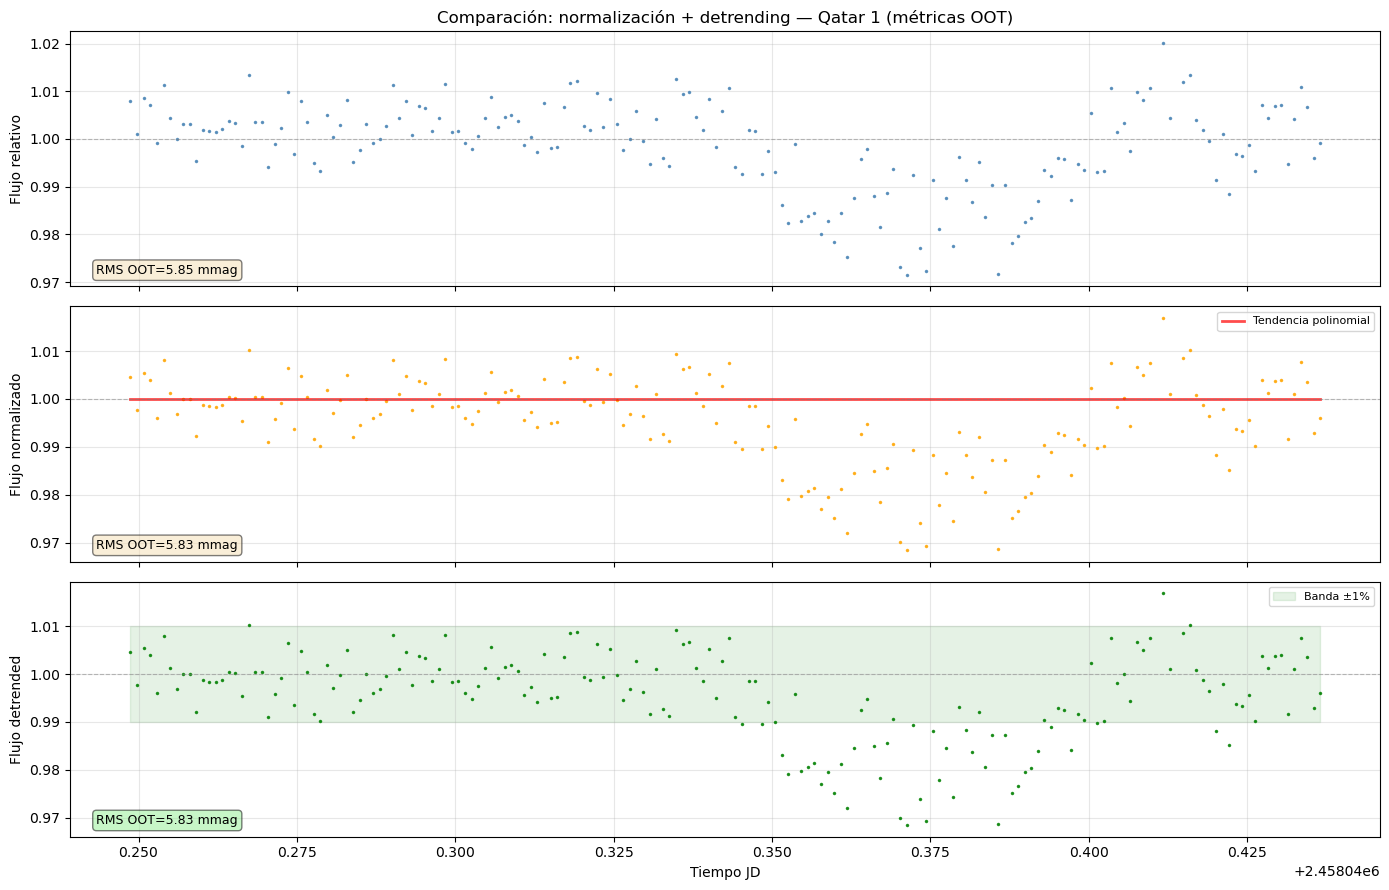

Resumen (solo OOT):
  RMS OOT original   : 5.853 mmag
  RMS OOT normalizado: 5.834 mmag
  RMS OOT detrended  : 5.834 mmag


In [8]:
fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

time_col = 'time_jd' if 'time_jd' in lc_detrended.columns and lc_detrended['time_jd'].notna().any() else 'frame_index'
x_label  = 'Tiempo JD' if time_col == 'time_jd' else 'Índice de frame'

oot_mask = ~lc_detrended['in_transit_mask'].astype(bool)
resid_orig_oot = (lc_detrended.loc[oot_mask, 'relative_flux'] - 1.0).to_numpy(dtype=float)
resid_norm_oot = (lc_detrended.loc[oot_mask, 'normalized_flux'] - 1.0).to_numpy(dtype=float)
resid_det_oot  = (lc_detrended.loc[oot_mask, 'detrended_flux'] - 1.0).to_numpy(dtype=float)

rms_orig_oot = float(np.std(resid_orig_oot, ddof=1)) * 1000.0
rms_norm_oot = float(np.std(resid_norm_oot, ddof=1)) * 1000.0
rms_det_oot  = float(np.std(resid_det_oot, ddof=1)) * 1000.0

# Panel 1: Flujo relativo original (métricas OOT)
axes[0].plot(lc_detrended[time_col], lc_detrended['relative_flux'], '.', color='steelblue', ms=3, alpha=0.8)
axes[0].axhline(1.0, color='gray', lw=0.8, linestyle='--', alpha=0.5)
axes[0].set_ylabel('Flujo relativo')
axes[0].set_title(f'Comparación: normalización + detrending — {OBJECT_NAME} (métricas OOT)')
axes[0].grid(True, alpha=0.3)
axes[0].text(
    0.02,
    0.05,
    f"RMS OOT={rms_orig_oot:.2f} mmag",
    transform=axes[0].transAxes,
    fontsize=9,
    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
)

# Panel 2: Flujo normalizado (sin detrending aún)
axes[1].plot(lc_detrended[time_col], lc_detrended['normalized_flux'], '.', color='orange', ms=3, alpha=0.8)
axes[1].plot(lc_detrended[time_col], lc_detrended['trend'], '-', color='red', lw=2, alpha=0.7, label='Tendencia polinomial')
axes[1].axhline(1.0, color='gray', lw=0.8, linestyle='--', alpha=0.5)
axes[1].set_ylabel('Flujo normalizado')
axes[1].grid(True, alpha=0.3)
axes[1].legend(fontsize=8)
axes[1].text(
    0.02,
    0.05,
    f"RMS OOT={rms_norm_oot:.2f} mmag",
    transform=axes[1].transAxes,
    fontsize=9,
    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
)

# Panel 3: Flujo detrended (final)
axes[2].plot(lc_detrended[time_col], lc_detrended['detrended_flux'], '.', color='green', ms=3, alpha=0.8)
axes[2].axhline(1.0, color='gray', lw=0.8, linestyle='--', alpha=0.5)
axes[2].fill_between(lc_detrended[time_col], 0.99, 1.01, alpha=0.1, color='green', label='Banda ±1%')
axes[2].set_ylabel('Flujo detrended')
axes[2].set_xlabel(x_label)
axes[2].grid(True, alpha=0.3)
axes[2].legend(fontsize=8)
axes[2].text(
    0.02,
    0.05,
    f"RMS OOT={rms_det_oot:.2f} mmag",
    transform=axes[2].transAxes,
    fontsize=9,
    bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5),
)

plt.tight_layout()
plt.show()

print('Resumen (solo OOT):')
print(f'  RMS OOT original   : {rms_orig_oot:.3f} mmag')
print(f'  RMS OOT normalizado: {rms_norm_oot:.3f} mmag')
print(f'  RMS OOT detrended  : {rms_det_oot:.3f} mmag')

## 7b · Filtrado de outliers OOT (>3σ)

Filtra automáticamente los puntos OOT que se desvían más de 3σ del nivel OOT. Se muestra el RMS OOT antes y después del filtrado, y se visualizan los outliers en la curva.

RMS OOT antes del filtrado:   5.834 mmag
RMS OOT tras excluir outliers: 5.656 mmag
Outliers OOT detectados (>3σ): 1


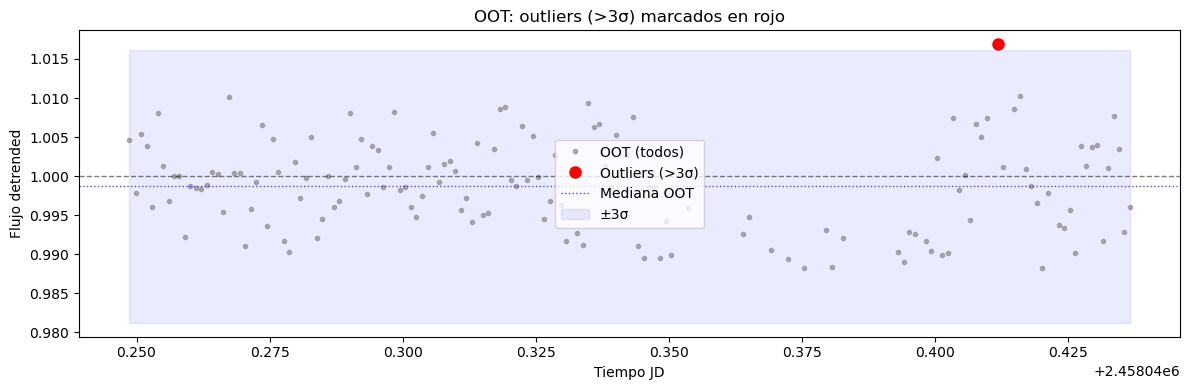

In [9]:
# --- Filtrado de outliers OOT (>3σ) ---
oot_mask = ~lc_detrended['in_transit_mask'].astype(bool)
oot_flux = lc_detrended.loc[oot_mask, 'detrended_flux']
oot_time = lc_detrended.loc[oot_mask, time_col] if 'time_col' in locals() else lc_detrended.loc[oot_mask, 'frame_index']
oot_resid = oot_flux - 1.0
rms_oot_pre = float(np.std(oot_resid, ddof=1)) * 1000.0
med_oot = np.median(oot_flux)
std_oot = np.std(oot_flux, ddof=1)
outlier_mask = np.abs(oot_flux - med_oot) > 3 * std_oot
n_outliers = int(outlier_mask.sum())

# Excluir outliers
oot_flux_clipped = oot_flux[~outlier_mask]
rms_oot_post = float(np.std(oot_flux_clipped - 1.0, ddof=1)) * 1000.0

print(f'RMS OOT antes del filtrado:   {rms_oot_pre:.3f} mmag')
print(f'RMS OOT tras excluir outliers: {rms_oot_post:.3f} mmag')
print(f'Outliers OOT detectados (>3σ): {n_outliers}')

# Visualización
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(oot_time, oot_flux, '.', color='gray', alpha=0.6, label='OOT (todos)')
ax.plot(oot_time[outlier_mask], oot_flux[outlier_mask], 'o', color='red', ms=8, label='Outliers (>3σ)')
ax.axhline(1.0, color='k', lw=1, ls='--', alpha=0.5)
ax.axhline(med_oot, color='blue', lw=1, ls=':', alpha=0.7, label='Mediana OOT')
ax.fill_between(oot_time, med_oot-3*std_oot, med_oot+3*std_oot, color='blue', alpha=0.08, label='±3σ')
ax.set_ylabel('Flujo detrended')
ax.set_xlabel(x_label)
ax.set_title('OOT: outliers (>3σ) marcados en rojo')
ax.legend()
plt.tight_layout()
plt.show()

## 8 · Diagnóstico: flujo por comparadora

Comprueba que las comparadoras son estables entre sí. Una comparadora variable se detecta
porque su flujo individual no sigue el mismo patrón que el resto.

In [ ]:
ap = pd.read_csv(PHOT_DIR / 'aperture_photometry.csv')
comp_data = ap[ap['role'] == 'comparison'].copy()

fig, ax = plt.subplots(figsize=(14, 5))
for source_id, group in comp_data.groupby('source_id'):
    norm_flux = group['net_flux'] / group['net_flux'].median()
    x_vals = group['time_jd'] if 'time_jd' in group.columns and group['time_jd'].notna().any() else group['frame_index']
    ax.plot(x_vals, norm_flux, '.', ms=2, alpha=0.7, label=source_id)

ax.axhline(1.0, color='gray', lw=0.8, linestyle='--')
ax.set_ylabel('Flujo normalizado a mediana')
ax.set_xlabel(x_label)
ax.set_title('Flujo individual por comparadora (normalizadas)')
ax.legend(fontsize=8, markerscale=3)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()